# Codigo Final

In [ ]:
# ╔════════════════════════════════════════════════════════════════╗
# 0. INSTALACIÓN (solo la 1ª vez en Colab)                         ║
# ╚════════════════════════════════════════════════════════════════╝
!pip install deap -q

import pandas as pd
import numpy as np
import random
import warnings

# ╔════════════════════════════════════════════════════════════════╗
# 1. PARÁMETROS GLOBALES                                           ║
# ╚════════════════════════════════════════════════════════════════╝
DATA_DIR            = "/content"   # carpeta con ratings.csv y movies.csv
K_RECOMMEND         = 10          # tamaño de la lista final
MIN_GENRES          = 3            # restricción de variedad de géneros
POPULAR_PERC_MAX    = 0.90         # máx. percentil de popularidad admitido
POP_SIZE            = 120          # población NSGA‑II
N_GEN               = 60           # generaciones
SEED                = 42
random.seed(SEED); np.random.seed(SEED)

import pandas as pd, numpy as np, random, warnings
from sklearn.metrics.pairwise import cosine_similarity
from numpy.linalg import norm
from deap import base, creator, tools, algorithms
warnings.filterwarnings("ignore", category=FutureWarning)

# ╔════════════════════════════════════════════════════════════════╗
# 2. CARGA Y PREPROCESAMIENTO                                      ║
# ╚════════════════════════════════════════════════════════════════╝
ratings = pd.read_csv(f"{DATA_DIR}/ratings.csv")
movies  = pd.read_csv(f"{DATA_DIR}/movies.csv")[['movieId', 'title', 'genres']]
movies['genres'] = movies['genres'].str.split('|')

# Matriz binaria de géneros (película × género)
movies_expl = (movies.explode('genres')
                     .query('genres != "(no genres listed)"')
                     .assign(flag=1))
genre_mat = movies_expl.pivot_table(index='movieId',
                                    columns='genres',
                                    values='flag',
                                    fill_value=0)
genre_vec = {mid: genre_mat.loc[mid].values.astype(np.float32)
             for mid in genre_mat.index}

# Popularidad normalizada
pop_counts = ratings.groupby('movieId').size()
pop_norm   = ((pop_counts - pop_counts.min()) /
              (pop_counts.max() - pop_counts.min())).to_dict()
def novelty(mid):        # 1 ➜ nada popular
    return 1 - pop_norm.get(mid, 0)

# ╔════════════════════════════════════════════════════════════════╗
# 3. PERFIL DEL USUARIO Y PRECISIÓN PERSONALIZADA                  ║
# ╚════════════════════════════════════════════════════════════════╝
def user_profile(uid):
    rows = ratings[ratings.userId == uid]
    rows = rows[rows.movieId.isin(genre_vec)]      # solo películas con géneros
    if rows.empty:
        return np.zeros(len(genre_mat.columns), dtype=np.float32)
    vecs = np.stack([genre_vec[m] for m in rows.movieId])
    w    = rows.rating.values
    prof = np.average(vecs, axis=0, weights=w)
    nrm  = norm(prof)
    return prof / nrm if nrm else prof

def precision_score(profile, mid):
    v = genre_vec[mid]
    n = norm(profile)*norm(v)
    return float(np.dot(profile, v) / n) if n else 0.0

# ╔════════════════════════════════════════════════════════════════╗
# 4. DIVERSIDAD: MEDIA DE DISTANCIAS COSENO DENTRO DE LA LISTA     ║
# ╚════════════════════════════════════════════════════════════════╝
def cosine_diversity(mids):
    if len(mids) < 2:
        return 0.0
    vecs = [genre_vec[m] for m in mids]
    sim  = cosine_similarity(vecs)
    dist = 1 - sim
    k    = len(mids)
    return dist.sum() / (k*(k-1))

# ╔════════════════════════════════════════════════════════════════╗
# 5. NSGA‑II PARA OBTENER RECOMENDACIONES                          ║
# ╚════════════════════════════════════════════════════════════════╝
def nsga_recommend(uid, k=K_RECOMMEND,
                   pop_size=POP_SIZE, ngen=N_GEN):

    seen = set(ratings.loc[ratings.userId == uid, 'movieId'])
    profile = user_profile(uid)

    # --- candidatos que cumplan popularidad y tengan vector de géneros ---
    candidates = [m for m in movies.movieId
                  if m not in seen
                  and m in genre_vec
                  and novelty(m) >= (1 - POPULAR_PERC_MAX)]

    if len(candidates) < k:
        raise ValueError("No hay suficientes candidatos tras las restricciones.")

    idx2mid = candidates
    mid2idx = {m: i for i, m in enumerate(idx2mid)}

    # ----- DEAP: tipos -----
    if "FitnessM" not in creator.__dict__:
        creator.create("FitnessM", base.Fitness, weights=(1.0, 1.0, 1.0))
    if "Individual" not in creator.__dict__:
        creator.create("Individual", list, fitness=creator.FitnessM)

    toolbox = base.Toolbox()
    toolbox.register("attr_movie", lambda: random.randrange(len(candidates)))
    toolbox.register("individual", tools.initRepeat,
                     creator.Individual, toolbox.attr_movie, k)
    toolbox.register("population", tools.initRepeat, list, toolbox.individual)

    # ------- evaluación 3‑objetivos -------
    def eval_ind(ind):
        mids = [idx2mid[i] for i in ind]
        if len(set(mids)) < k:                               # duplicados
            return 0., 0., 0.
        genres_set = {g for m in mids for g in movies.loc[movies.movieId == m,
                                                          'genres'].iloc[0]}
        if len(genres_set) < MIN_GENRES:                    # variedad de géneros
            return 0., 0., 0.
        prec = np.mean([precision_score(profile, m) for m in mids])
        nov  = np.mean([novelty(m)            for m in mids])
        div  = cosine_diversity(mids)
        return prec, nov, div

    toolbox.register("evaluate", eval_ind)
    toolbox.register("mate",    tools.cxTwoPoint)
    toolbox.register("mutate",  tools.mutUniformInt,
                     low=0, up=len(candidates)-1, indpb=0.3)
    toolbox.register("select",  tools.selNSGA2)

    pop = toolbox.population(pop_size)
    algorithms.eaMuPlusLambda(pop, toolbox,
                              mu=pop_size, lambda_=pop_size,
                              cxpb=0.6, mutpb=0.4,
                              ngen=ngen, verbose=False)

    pareto_front = tools.sortNondominated(pop, k=1,
                                          first_front_only=True)[0][0]
    best_mids   = [idx2mid[i] for i in pareto_front]
    best_scores = pareto_front.fitness.values
    return best_mids, best_scores

# ╔════════════════════════════════════════════════════════════════╗
# 6. REGISTRO RÁPIDA DE UN USUARIO NUEVO                           ║
# ╚════════════════════════════════════════════════════════════════╝
def add_new_user(prefs: dict):
    """prefs = {movieId: rating}. Devuelve nuevo userId."""
    global ratings, user_mean

    new_id = int(ratings['userId'].max() + 1)
    df_new = pd.DataFrame({
        'userId':    new_id,
        'movieId':   list(prefs.keys()),
        'rating':    list(prefs.values()),
        'timestamp': 0
    })
    ratings = pd.concat([ratings, df_new], ignore_index=True)
    user_mean = ratings.groupby('userId')['rating'].mean().to_dict()
    return new_id

# ╔════════════════════════════════════════════════════════════════╗
# 7. DEMOSTRACIÓN                                                  ║
# ╚════════════════════════════════════════════════════════════════╝
print("⏳ Ejecutando NSGA‑II para el usuario 1 ...")
rec1, score1 = nsga_recommend(uid=1)
print("Precisión, Novedad, Diversidad →",
      [round(s, 4) for s in score1])
print("\n🍿 Recomendaciones para el usuario 1")
rr1 = movies.set_index('movieId').loc[rec1, ['title', 'genres']]
rr1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.6/135.6 kB 5.8 MB/s eta 0:00:00
⏳ Ejecutando NSGA‑II para el usuario 1 ...
Precisión, Novedad, Diversidad → [np.float64(0.6194), np.float64(0.9085), np.float32(0.6594)]

🍿 Recomendaciones para el usuario 1


,title,genres
movieId,,
73321,"Book of Eli, The (2010)","[Action, Adventure, Drama]"
152079,London Has Fallen (2016),"[Action, Crime, Thriller]"
2735,"Golden Child, The (1986)","[Action, Adventure, Comedy, Fantasy, Mystery]"
5944,Star Trek: Nemesis (2002),"[Action, Drama, Sci-Fi, Thriller]"
7143,"Last Samurai, The (2003)","[Action, Adventure, Drama, War]"
27790,Millions (2004),"[Children, Comedy, Crime, Drama, Fantasy]"
61248,Death Race (2008),"[Action, Adventure, Sci-Fi, Thriller]"
317,"Santa Clause, The (1994)","[Comedy, Drama, Fantasy]"
2599,Election (1999),[Comedy]


In [ ]:

print("\n⏳ Creando un usuario nuevo con gustos específicos ...")
new_uid = add_new_user({1: 5, 32: 4, 296: 4.5})
rec2, score2 = nsga_recommend(uid=new_uid)
print("Precisión, Novedad, Diversidad →",
      [round(s, 4) for s in score2])
print(f"\n🍿 Recomendaciones para el usuario {new_uid}")
rr2= movies.set_index('movieId').loc[rec2, ['title', 'genres']]
rr2


⏳ Creando un usuario nuevo con gustos específicos ...
Precisión, Novedad, Diversidad → [np.float64(0.4764), np.float64(0.9634), np.float32(0.8406)]

🍿 Recomendaciones para el usuario 611


,title,genres
movieId,,
168218,Kizumonogatari III: Cold Blood (2017),"[Animation, Fantasy, Mystery]"
56915,"Water Horse: Legend of the Deep, The (2007)","[Adventure, Children, Fantasy]"
3969,Pay It Forward (2000),[Drama]
112868,"Signal, The (2014)","[Sci-Fi, Thriller]"
2490,Payback (1999),"[Action, Thriller]"
1376,Star Trek IV: The Voyage Home (1986),"[Adventure, Comedy, Sci-Fi]"
6920,"Cercle Rouge, Le (Red Circle, The) (1970)","[Crime, Thriller]"
8796,"Funny Thing Happened on the Way to the Forum, ...","[Comedy, Musical]"
86059,Hop (2011),"[Animation, Children, Comedy]"


# Codigos sacar informacion de las tablas

## Codigo las peliculas que el usuario a calificado

In [ ]:
import pandas as pd

def get_user_preferences(uid: int,
                         ratings_df: pd.DataFrame,
                         movies_df: pd.DataFrame,
                         min_rating: float | None = None) -> pd.DataFrame:
    """
    Devuelve un DataFrame con las películas que ha puntuado un usuario
    y la calificación que les dio.

    Parámetros
    ----------
    uid : int
        userId del usuario de interés.
    ratings_df : pd.DataFrame
        Tabla de ratings (userId, movieId, rating, timestamp).
    movies_df : pd.DataFrame
        Tabla de películas (movieId, title, genres).
    min_rating : float | None
        Umbral mínimo de rating para considerar “gustos”.
        Si es None se muestran todas las calificaciones.

    Returns
    -------
    pd.DataFrame
        Columnas: title, rating  (ordenado por rating descendente).
    """
    # 1. Unir ratings con títulos de película
    merged = ratings_df.merge(movies_df[['movieId', 'title']], on='movieId')

    # 2. Filtrar solo las filas del usuario
    user_rows = merged[merged['userId'] == uid]

    # 3. Si se pide, aplicar umbral mínimo de rating
    if min_rating is not None:
        user_rows = user_rows[user_rows['rating'] >= min_rating]

    # 4. Devolver título y rating, ordenados por nota
    return (user_rows[['title', 'rating']]
            .sort_values(by='rating', ascending=False)
            .reset_index(drop=True))

# ───────────────── Ejemplo de uso ─────────────────
# Preferencias “claras” del usuario 1 (rating ≥ 4★)
prefs_u1 = get_user_preferences(uid=613,
                                ratings_df=ratings,
                                movies_df=movies,
                                min_rating= None)

prefs_u1.head(1000)   # muestra las 10 más altas


,title,rating


## Codigos para gráficar prentes de Pareto


Usuario creado: 611
                                       title  rating
0                           Toy Story (1995)     5.0
1                        Pulp Fiction (1994)     4.5
2  Twelve Monkeys (a.k.a. 12 Monkeys) (1995)     4.0

Precis, Novedad, Diversidad: [np.float64(0.2569), np.float64(0.9982), np.float32(0.9741)]
                                                     title  \
movieId                                                      
2727                                  Killer's Kiss (1955)   
146028   The Adventures of Sherlock Holmes and Dr. Wats...   
130450                                          Pan (2015)   
136834                            The Eye: Infinity (2005)   
1137                                  Hustler White (1996)   
4294                    5,000 Fingers of Dr. T, The (1953)   
161032                              The Grandmother (1970)   
2185                                      I Confess (1953)   
81018            Illusionist, The (L'illusionniste) (2010

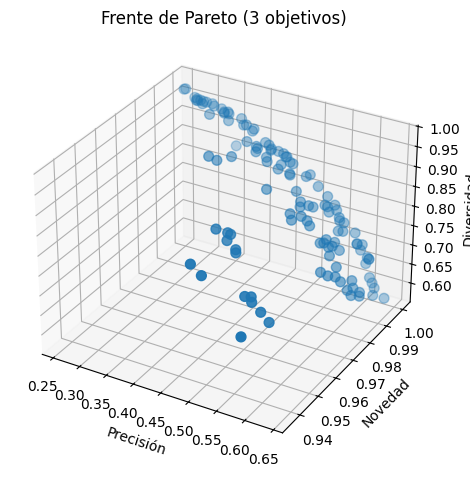

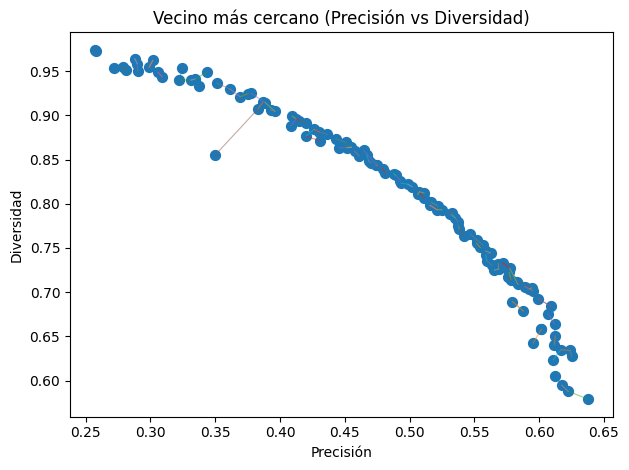

In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# 0. INSTALACIÓN DE DEPENDENCIAS (solo la 1ª vez en Colab)       ║
# ╚══════════════════════════════════════════════════════════════╝
!pip install deap -q

# ╔══════════════════════════════════════════════════════════════╗
# 1. PARÁMETROS Y CARGA DE DATOS                                 ║
# ╚══════════════════════════════════════════════════════════════╝
import pandas as pd, numpy as np, random, warnings
from sklearn.metrics.pairwise import cosine_similarity
from numpy.linalg import norm
from deap import base, creator, tools, algorithms
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.metrics import pairwise_distances

DATA_DIR            = "/content"   # ruta donde están los CSV
K_RECOMMEND         = 10
MIN_GENRES          = 3
POPULAR_PERC_MAX    = 0.90
POP_SIZE            = 120
N_GEN               = 60
SEED                = 42
random.seed(SEED); np.random.seed(SEED)
warnings.filterwarnings("ignore", category=FutureWarning)

ratings = pd.read_csv(f"{DATA_DIR}/ratings.csv")
movies  = pd.read_csv(f"{DATA_DIR}/movies.csv")[['movieId', 'title', 'genres']]
movies['genres'] = movies['genres'].str.split('|')

# Matriz binaria de géneros
movies_expl = (movies.explode('genres')
                     .query('genres != "(no genres listed)"')
                     .assign(flag=1))
genre_mat = movies_expl.pivot_table(index='movieId',
                                    columns='genres',
                                    values='flag',
                                    fill_value=0)
genre_vec = {mid: genre_mat.loc[mid].values.astype(np.float32)
             for mid in genre_mat.index}

# Popularidad normalizada
pop_counts = ratings.groupby('movieId').size()
pop_norm   = ((pop_counts - pop_counts.min())
             /(pop_counts.max() - pop_counts.min())).to_dict()
def novelty(mid): return 1 - pop_norm.get(mid, 0)

# ╔══════════════════════════════════════════════════════════════╗
# 2. PERFIL DE USUARIO Y MÉTRICAS                                ║
# ╚══════════════════════════════════════════════════════════════╝
def user_profile(uid:int)->np.ndarray:
    rows = ratings[ratings.userId == uid]
    rows = rows[rows.movieId.isin(genre_vec)]
    if rows.empty:
        return np.zeros(len(genre_mat.columns), np.float32)
    vecs = np.stack([genre_vec[m] for m in rows.movieId])
    w    = rows.rating.values
    prof = np.average(vecs, axis=0, weights=w)
    nrm  = norm(prof)
    return prof / nrm if nrm else prof

def precision_score(profile:np.ndarray, mid:int)->float:
    v = genre_vec[mid]
    n = norm(profile)*norm(v)
    return float(np.dot(profile, v) / n) if n else 0.0

def cosine_diversity(mids:list[int])->float:
    if len(mids) < 2: return 0.0
    vecs = [genre_vec[m] for m in mids]
    dist = 1 - cosine_similarity(vecs)
    k = len(mids)
    return dist.sum() / (k*(k-1))

# ╔══════════════════════════════════════════════════════════════╗
# 3. ALTA RÁPIDA DE USUARIO Y EXTRACCIÓN DE GUSTOS               ║
# ╚══════════════════════════════════════════════════════════════╝
def add_new_user(prefs:dict)->int:
    """prefs = {movieId: rating}"""
    global ratings
    new_id = int(ratings['userId'].max() + 1)
    df_new = pd.DataFrame({'userId':new_id,
                           'movieId':list(prefs.keys()),
                           'rating':list(prefs.values()),
                           'timestamp':0})
    ratings = pd.concat([ratings, df_new], ignore_index=True)
    return new_id

def get_user_preferences(uid:int,
                         min_rating:float|None=None)->pd.DataFrame:
    merged = ratings.merge(movies[['movieId','title']], on='movieId')
    user_rows = merged[merged.userId == uid]
    if min_rating is not None:
        user_rows = user_rows[user_rows.rating >= min_rating]
    return (user_rows[['title','rating']]
            .sort_values('rating', ascending=False)
            .reset_index(drop=True))

# ╔══════════════════════════════════════════════════════════════╗
# 4. FUNCIÓN NSGA-II (devuelve también pop)                      ║
# ╚══════════════════════════════════════════════════════════════╝
def nsga_recommend(uid:int, k:int=K_RECOMMEND,
                   pop_size:int=POP_SIZE, ngen:int=N_GEN):
    seen = set(ratings.loc[ratings.userId==uid,'movieId'])
    profile = user_profile(uid)

    candidates = [m for m in movies.movieId
                  if m not in seen
                  and m in genre_vec
                  and novelty(m) >= 1-POPULAR_PERC_MAX]
    if len(candidates) < k:
        raise ValueError("Candidatos insuficientes.")
    idx2mid = candidates
    mid2idx = {m:i for i,m in enumerate(idx2mid)}

    if "FitnessM" not in creator.__dict__:
        creator.create("FitnessM", base.Fitness, weights=(1,1,1))
    if "Individual" not in creator.__dict__:
        creator.create("Individual", list, fitness=creator.FitnessM)

    toolbox = base.Toolbox()
    toolbox.register("attr_movie", lambda: random.randrange(len(candidates)))
    toolbox.register("individual", tools.initRepeat,
                     creator.Individual, toolbox.attr_movie, k)
    toolbox.register("population", tools.initRepeat, list, toolbox.individual)

    def eval_ind(ind):
        mids = [idx2mid[i] for i in ind]
        if len(set(mids))<k: return 0,0,0
        genres_set = {g for m in mids for g in
                      movies.loc[movies.movieId==m,'genres'].iloc[0]}
        if len(genres_set)<MIN_GENRES: return 0,0,0
        prec = np.mean([precision_score(profile,m) for m in mids])
        nov  = np.mean([novelty(m) for m in mids])
        div  = cosine_diversity(mids)
        return prec, nov, div

    toolbox.register("evaluate", eval_ind)
    toolbox.register("mate", tools.cxTwoPoint)
    toolbox.register("mutate", tools.mutUniformInt,
                     low=0, up=len(candidates)-1, indpb=0.3)
    toolbox.register("select", tools.selNSGA2)

    pop = toolbox.population(pop_size)
    algorithms.eaMuPlusLambda(pop, toolbox,
                              mu=pop_size, lambda_=pop_size,
                              cxpb=0.6, mutpb=0.4,
                              ngen=ngen, verbose=False)

    pareto_front = tools.sortNondominated(pop, k=1,
                                          first_front_only=True)[0][0]
    best_mids   = [idx2mid[i] for i in pareto_front]
    best_scores = pareto_front.fitness.values
    return best_mids, best_scores, pop

# ╔══════════════════════════════════════════════════════════════╗
# 5. DEMOSTRACIÓN COMPLETA                                       ║
# ╚══════════════════════════════════════════════════════════════╝
# A) Crear un usuario nuevo con preferencias
prefs = {1:5, 32:4, 296:4.5}
uid_new = add_new_user(prefs)
print(f"Usuario creado: {uid_new}")
print(get_user_preferences(uid_new))

# B) Ejecutar NSGA-II y obtener pop
rec, scores, pop = nsga_recommend(uid_new)
print("\nPrecis, Novedad, Diversidad:", [round(s,4) for s in scores])
print(movies.set_index('movieId').loc[rec, ['title','genres']])

# ╔══════════════════════════════════════════════════════════════╗
# 6. GRÁFICAS: Frente + Vecinos                                  ║
# ╚══════════════════════════════════════════════════════════════╝
pareto = tools.sortNondominated(pop, k=len(pop), first_front_only=True)[0]
pts = np.array([ind.fitness.values for ind in pareto])

fig1 = plt.figure()
ax1 = fig1.add_subplot(111, projection='3d')
ax1.scatter(pts[:,0], pts[:,1], pts[:,2], s=50)
ax1.set_xlabel('Precisión'); ax1.set_ylabel('Novedad'); ax1.set_zlabel('Diversidad')
ax1.set_title('Frente de Pareto (3 objetivos)')
plt.tight_layout(); plt.show()

dist = pairwise_distances(pts); np.fill_diagonal(dist, np.inf)
nn = dist.argmin(axis=1)

fig2, ax2 = plt.subplots()
ax2.scatter(pts[:,0], pts[:,2], s=50)
for i,j in enumerate(nn):
    ax2.plot([pts[i,0], pts[j,0]], [pts[i,2], pts[j,2]],
             alpha=0.5, lw=0.8)
ax2.set_xlabel('Precisión'); ax2.set_ylabel('Diversidad')
ax2.set_title('Vecino más cercano (Precisión vs Diversidad)')
plt.tight_layout(); plt.show()
